In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
data = pd.read_csv("digital_addiction_dataset.csv")

data.head()

,screen_time,social_media_hours,gaming_hours,sleep_hours,phone_pickups,mood_score,addiction_risk
0,5.869022,7.605714,4.391964,6.591951,112,10,Moderate
1,3.027929,0.464669,5.197057,6.606690,161,3,Low
2,1.267598,7.759279,4.994656,4.274035,197,5,Moderate
3,9.027260,4.893225,0.042398,3.138375,68,10,Moderate
4,1.606654,7.790044,1.396628,3.543639,199,3,Moderate


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   screen_time         500 non-null    float64
 1   social_media_hours  500 non-null    float64
 2   gaming_hours        500 non-null    float64
 3   sleep_hours         500 non-null    float64
 4   phone_pickups       500 non-null    int64  
 5   mood_score          500 non-null    int64  
 6   addiction_risk      500 non-null    object 
dtypes: float64(4), int64(2), object(1)
memory usage: 27.5+ KB


In [4]:
X = data.drop("addiction_risk", axis=1)
y = data["addiction_risk"]

X.head()

,screen_time,social_media_hours,gaming_hours,sleep_hours,phone_pickups,mood_score
0,5.869022,7.605714,4.391964,6.591951,112,10
1,3.027929,0.464669,5.197057,6.606690,161,3
2,1.267598,7.759279,4.994656,4.274035,197,5
3,9.027260,4.893225,0.042398,3.138375,68,10
4,1.606654,7.790044,1.396628,3.543639,199,3


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 6)
Testing Data: (100, 6)


In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
y_pred = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1
         Low       1.00      1.00      1.00        42
    Moderate       1.00      1.00      1.00        57

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



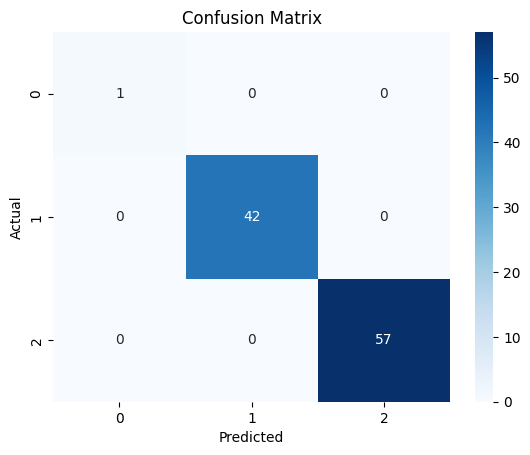

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
sample_input = [[9, 5, 3, 4, 150, 3]]
# screen_time, social_media, gaming, sleep, pickups, mood

prediction = model.predict(sample_input)

print("Predicted Addiction Risk:", prediction[0])

Predicted Addiction Risk: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


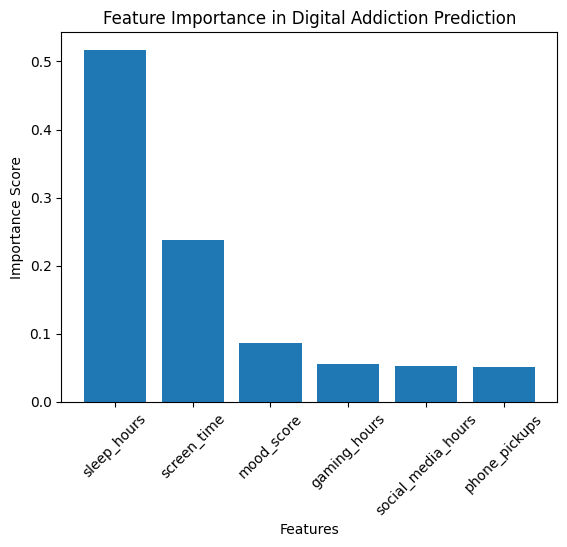

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Plot
plt.figure()
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Digital Addiction Prediction")
plt.show()